In [82]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.signal import find_peaks

import logging
formatter = "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
logging.basicConfig(level=logging.INFO, format=formatter)
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")

In [83]:
def load_txt(file_path: Path, sort_x: bool = True) -> pd.DataFrame:
    try:
        df = pd.read_csv(file_path, sep=r"\s+", header=None, names=["X", "Y"])
        df = df.dropna()
        if sort_x:
            df = df.sort_values("X")
        return df.reset_index(drop=True)
    except Exception as exc:
        logger.error("Failed to load %s: %s", file_path, exc)
        return pd.DataFrame(columns=["X", "Y"])

In [84]:
def plot_raman(df: pd.DataFrame, title: str = "Raman Spectrum") -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(x="X", y="Y", data=df, ax=ax)

    # RBM 領域
    rbm_range = (100, 300)
    ax.axvspan(rbm_range[0], rbm_range[1], color="yellow", alpha=0.3)

    # ピーク位置の検出
    x = df["X"].values
    intensity = df["Y"].values

    def get_peak(xmin, xmax):
        mask = (x >= xmin) & (x <= xmax)
        idx = np.argmax(intensity[mask])
        return x[mask][idx], intensity[mask][idx]   # (位置, 強度) を返す

    d_peak,     d_int     = get_peak(1300, 1400)
    g_m_peak,   g_m_int   = get_peak(1530, 1560)
    g_peak,     g_int     = get_peak(1570, 1610)
    two_d_peak, two_d_int = get_peak(2600, 2800)

    # ピークラベル（ピーク強度の少し上・黒色）
    offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03  # y幅の3%分上

    for peak, peak_int, label, x_offset in [
        (d_peak,     d_int,     "D", 0),
        (g_m_peak,   g_m_int,   "G⁻", -50),
        (g_peak,     g_int,     "G", 0),
        (two_d_peak, two_d_int, "2D", 0),
    ]:
        ax.text(int(peak) + x_offset, peak_int + offset, label,
                color="black", fontsize=14, fontweight="bold",
                ha="center", va="bottom")

    # RBM ラベル（領域中央・黒色）
    rbm_center_x = (rbm_range[0] + rbm_range[1]) / 2
    rbm_center_y = ax.get_ylim()[1] * 0.35
    ax.text(rbm_center_x, rbm_center_y, "RBM",
            color="black", fontsize=14, fontweight="bold",
            ha="center", va="center")

    # y軸を 10^n 形式に変更
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

    # ×10^n のフォントサイズを16に設定 ★
    ax.yaxis.get_offset_text().set_fontsize(16)

    ax.set_title(title)
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=18)
    ax.set_ylabel("Intensity (a.u.)", fontsize=18)
    ax.set_ylim(0, intensity.max() * 1.2)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid()
    plt.tight_layout()
    plt.show()

In [145]:
def plot_raman_zoom(df: pd.DataFrame, title: str = "Raman Spectrum", plot_range: tuple = (200, 300)) -> None:
    x = df["X"].values
    y = df["Y"].values
    mask = (x >= plot_range[0]) & (x <= plot_range[1])
    x_range = x[mask]
    y_range = y[mask]
    max_y = y_range.max()
    max_x = x_range[y_range.argmax()]

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(x="X", y="Y", data=df, ax=ax)
    # ax.axvline(x=max_x, color="red", linestyle="--", linewidth=1.5,
    #            label=f"Max: {max_x:.1f} cm⁻¹")
    ax.set_xlim(plot_range)
    ax.set_ylim(0, max_y * 1.1)

    # y軸を 10^n 形式に変更 ★
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    ax.yaxis.set_major_formatter(formatter)
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(16)

    ax.set_title(title)
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=22)
    ax.set_ylabel("Intensity (a.u.)", fontsize=22)
    # x軸の表示を少し下に下げる
    ax.tick_params(axis="both", labelsize=20, pad=10)
    ax.legend(fontsize=16)
    ax.grid()
    plt.tight_layout()
    plt.show()

In [146]:
def plot_raman_rbm(
    df: pd.DataFrame,
    title: str = "Raman Spectrum (RBM)",
    plot_range: tuple = (100, 300),
    peak_height: float = 0.1,   # ピーク検出の最小高さ（正規化後）
    peak_distance: int = 5,     # ピーク間の最小距離（データ点数）
) -> None:

    x = df["X"].values
    y = df["Y"].values
    mask = (x >= plot_range[0]) & (x <= plot_range[1])
    x_range = x[mask]
    y_range = y[mask]

    # バックグラウンド除去（範囲内の最小値を引いてゼロベースに）
    y_bg = y_range - y_range.min()

    # 正規化（0 to 1）
    y_norm = y_bg / y_bg.max()

    # ピーク検出
    peak_indices, _ = find_peaks(y_norm, height=peak_height, distance=peak_distance)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_range, y_norm, color="steelblue", linewidth=1.5)

    # ピーク垂直線 ＋ ラベル（黒・ピーク直上）
    offset = 0.03   # ピーク上の余白
    for idx in peak_indices:
        peak_x = x_range[idx]
        peak_y = y_norm[idx]
        ax.axvline(x=peak_x, color="gray", linestyle="--", linewidth=1.0)
        ax.text(peak_x, peak_y + offset, f"{peak_x:.1f}",
                color="black", fontsize=16, fontweight="bold",
                ha="center", va="bottom")

    ax.set_xlim(plot_range)
    ax.set_ylim(-0.05, 1.1)   # 上部にラベル用の余白
    ax.set_title(title)
    ax.set_xlabel("Raman Shift (cm⁻¹)", fontsize=24)
    ax.set_ylabel("Normalized Intensity", fontsize=24)
    ax.tick_params(axis="both", labelsize=20)
    ax.grid()
    plt.tight_layout()
    plt.show()

/var/folders/3l/lksq85b54lnf2bvmtm64x0lh0000gn/T/ipykernel_6810/1927183905.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=16)


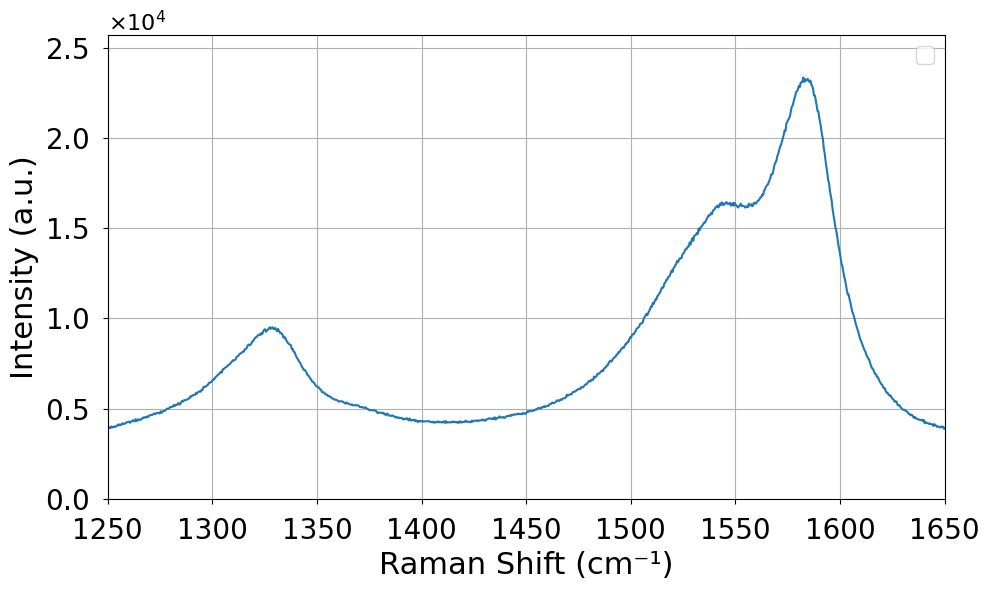

In [148]:
txt = Path("data/cnt/cnt_02_thin_acq5sx5_Laser50_x100_1800G_532nm.txt")
# txt = Path("data/cnt/cnt_03_thin_acq5sx5_Laser50_x100_1800G_633nm.txt")
df = load_txt(txt)
# plot_raman(df, title="")
plot_raman_zoom(df, title="", plot_range=(1250, 1650))
# plot_raman_rbm(df, title="", plot_range=(100, 300), peak_height=0.4, peak_distance=10)
# plot_raman_rbm(df, title="", plot_range=(100, 300), peak_height=0.12, peak_distance=30)